### This is the script to do normal NLP analysis for climate risk disclosure

Notice: You should only run this after running '1-explatorary_analysis.ipynb'. And this one only use nltk the normal NLP analysis type

In [ ]:
#!pip install nltk
#!pip install PyPDF2

In [94]:
import ast, re, time, os, requests
import pandas as pd
import numpy as np
from datetime import date
import seaborn as sns 
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import textwrap
#NLTK Imports
import nltk 
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import PyPDF2
np.NaN = np.nan

nltk.download('vader_lexicon')
nltk.download('stopwords')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\QuyenN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\QuyenN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [95]:
# Output folder for CSVs and PDFs — update if running on a different machine
FOLDER     = r'C:\Users\QuyenN\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure'
FIG_FOLDER =  r'C:\Users\QuyenN\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\5-Analysis2026'  
PDF_FOLDER = os.path.join(FOLDER, 'pdfs_2026','pdfs')


### First, explode the file into multipel pdf file

In [104]:
disclose_2026 = pd.read_csv(os.path.join(FIG_FOLDER, 'List_of_all_disclosures_as_of_2026_mapped.csv'))
#Explore 
disclose_2026['pdf_files'] = disclose_2026['pdf_files'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x
)

disclose_2026_exploded = (
    disclose_2026
    .explode('pdf_files')
    .dropna(subset=['pdf_files'])
    .reset_index(drop=True)
)


print(f'The number of disclosure is {disclose_2026.shape[0]}')
print(f'The number of disclosed PDF is {disclose_2026_exploded.shape[0]}')
#Then remove those without file
disclose_2026_exploded =disclose_2026_exploded[(disclose_2026_exploded['pdf_count']>0) ]
print(f'The number of disclosed PDF after remove those with 0 is {disclose_2026_exploded.shape[0]}')
# Then remove those with investment schemes 
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded['Type']!='Investment schemes']
print(f'The number of disclosed PDF for normal firms is {disclose_2026_exploded.shape[0]}')
# Then remove those in 2026 cohort 
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded['Cohort']!='Cohort 3 (Jul 2025 – Jun 2026)']
print(f'The number of disclosed PDF for normal firms in 2024-2025 is {disclose_2026_exploded.shape[0]}')
disclose_2026_exploded.to_csv(os.path.join(FIG_FOLDER, 'List_of_all_PDF_for_normal_companies.csv'))
# Then I have use a manual selection of PDF to be included
included_pdf = pd.read_csv(os.path.join(FIG_FOLDER, 'Included_PDF_only.csv'))
disclose_2026_exploded = pd.merge(disclose_2026_exploded,
                                  included_pdf,
                                  how = 'left',
                                  left_on = ['Company_Scheme', 'Cohort','pdf_files'],
                                  right_on =['Company_Scheme', 'Cohort','pdf_files'] )
disclose_2026_exploded = disclose_2026_exploded.drop_duplicates(subset = ['pdf_files'])
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded['FinalInclusion'] ==1]
# Rename investment schemes into Finance other 
disclose_2026_exploded['Industry'] = np.where(
    disclose_2026_exploded['Industry'] == 'Investment Schemes',
    'Finance - Other',
    disclose_2026_exploded['Industry']
)
disclose_2026_exploded['Industry'] = np.where(
    disclose_2026_exploded['Industry'] == 'Other (Industrials, Consumer, Tech, Transport, etc.)',
    'Other industries',
    disclose_2026_exploded['Industry']
)
print(f'The number of disclosed PDF for normal firms in 2024-2025 is {disclose_2026_exploded.shape[0]}')
#Remove one file 
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded["pdf_files"]!="CRD 2023 CEO Declaration.pdf"]
print(f'The number of disclosed PDF for normal firms in 2024-2025 is {disclose_2026_exploded.shape[0]}')
disclose_2026_exploded.to_csv(os.path.join(FIG_FOLDER, 'List_of_selected_PDF_forLLManalysis.csv'))


The number of disclosure is 743
The number of disclosed PDF is 3206
The number of disclosed PDF after remove those with 0 is 3206
The number of disclosed PDF for normal firms is 410
The number of disclosed PDF for normal firms in 2024-2025 is 410
The number of disclosed PDF for normal firms in 2024-2025 is 235
The number of disclosed PDF for normal firms in 2024-2025 is 234


In [105]:
disclose_2026_exploded.groupby(['Cohort']).size()

Cohort
FY23/24    113
FY24/25    121
dtype: int64

In [ ]:
### Breakdown by industry — Finance vs Non-Finance grouped
import textwrap

finance_industries = ['Finance - Banks', 'Finance - Insurance', 'Finance - Other']

pivot_table = disclose_2026_exploded.pivot_table(
    index='Industry', columns='Cohort', values='Company_Scheme', aggfunc='count'
)

# Sort each group by total (ascending → largest at top in barh)
def sort_by_total(df, idx):
    sub = df.loc[[i for i in idx if i in df.index]]
    return sub.loc[sub.sum(axis=1).sort_values().index].index.tolist()

fin_idx      = [i for i in pivot_table.index if i in finance_industries]
other_idx    = [i for i in pivot_table.index if i not in finance_industries]
fin_sorted   = sort_by_total(pivot_table, fin_idx)
other_sorted = sort_by_total(pivot_table, other_idx)

# Non-Finance at bottom, Finance at top
pivot_table = pivot_table.loc[other_sorted + fin_sorted]

n_other   = len(other_sorted)
n_finance = len(fin_sorted)
n_total   = len(pivot_table)


COHORT_COLORS = {'FY23/24': '#2166AC', 'FY24/25': '#F4A582'}
colors = [COHORT_COLORS[c] for c in pivot_table.columns]

fig, ax = plt.subplots(figsize=(10, max(4, n_total * 0.55)))
pivot_table.plot(kind='barh', stacked=False, ax=ax, color=colors,
                 edgecolor='black')
ax.grid(visible=False)
ax.tick_params(axis='x', labelsize=13)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title('Number of climate statements by industries in the final sample', fontweight='bold', fontsize=16)
ax.set_xlabel('Number of statements')
ax.set_ylabel('')
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

plt.tight_layout()
plt.savefig(os.path.join(FIG_FOLDER, 'Fig04_disclosure_overtime_by_industry.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### Now, let us define functions to run the NLP analysis 

In [29]:
#sentiment
sent = SentimentIntensityAnalyzer()
st = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))


## climate hazard datasets key words
drought = ['drought', 'severe drought', 'dry', 'SPI', 'standardised precipitation index', 'standardized precipitation index', 'rainfall', '10 minute average', 'topography']
winds= ['wind', 'extreme winds', 'cyclone','tsunami']
rainfall =['rain','pluvial','pluvial flooding','rainfall']
river = ['river','flood', 'river flooding', 'fluvial',
         'daily rainfall', 'river level', 'flow', 'soils', 'vegetation', 
        ]
coastal = ['coastal','flood','topography',  'sea-level', 'sea level', 'esl', 'extreme sea',
           'coastal flooding', 'inundation', 'groundwater','nearshore', 'bathymetry', 'bathymetric']
shoreline_change = ['shoreline change','aerial', 'aerial photography', 'historical aerial', 'topography', 'soils', 'soil', 'geology']
heatwave = ['heatwave', 'extreme temperature', 'humidity', 'rainfall', 'extreme heat', 'heat']
landslide =['landslide', 'soil', ' soil erosion', 'erosion', 'topography', 'geology', 'soils', 'vegetation', 'rainfall']
other = ['extreme event', 'extreme heat','extreme sea','extreme winds', 'disaster']
emissions = ['emission', 'carbon', 'ghg','greenhouse','methane',' ets ']
gns_related_words = [' gns', 'merit', 'riskscape','nigem','nz searise', 'groundwater', 'antarctica']
niwa_words = [' niwa']
## put climate hazards into a list to easily loop over
keywords= drought +  winds +  river +  coastal +  shoreline_change +  heatwave +  landslide + other + emissions + other +gns_related_words +niwa_words

In [30]:
# A function to get page text 
def get_pages_text(file_name):
    pages_text = {}
    with open(file_name, 'rb') as pdfFileObject:
        pdfReader = PyPDF2.PdfReader(pdfFileObject)

        print("No. of Pages:", len(pdfReader.pages))
        for i, page in enumerate(pdfReader.pages):
            pages_text[i] = page.extract_text()
    return pages_text 

# Clean data 
def clean_data(text):
    # change to lower and remove spaces on either side
    text =  text.lower().strip() 

    # remove extra spaces in between
    text = re.sub(' +', ' ', text)

    # remove punctuation
    text= re.sub('[^a-zA-Z]', ' ', text)

    # remove stopwords and get the stem
    text =  ' '.join(st.stem(x) for x in text.split() if x not in stop_words)
    return text

In [68]:
disclose_2026_exploded['Cohort'].unique()

array(['Cohort 2 (Jul 2024 – Jun 2025)', 'Cohort 1 (≤ Jun 2024)'],
      dtype=object)

In [72]:
#Simple analysis 
nlp_analysis = pd.DataFrame()
for i,row  in disclose_2026_exploded.iterrows():
    pdf_file = row['pdf_files']
    company = row['Company Name']
    period_year = row['period_year']
    period = row['PeriodDate']
    industry = row['Industry']
    cohort = row['Cohort']
    #Get safe name 
    safe_name = re.sub(r'[^\w\s-]', '', company)[:50].strip().replace(' ', '_') + f"_{period_year}"
    company_folder = os.path.join(PDF_FOLDER, safe_name)
    pdfs = glob.glob(os.path.join(company_folder, '*.pdf'))
    filename = os.path.join(PDF_FOLDER, safe_name,pdf_file)

    print(filename)
    try: 
        pages_text = get_pages_text(filename).values()
        pages_text_final = ' '.join(pages_text)
        #clean data 
        page_text_clean = clean_data(pages_text_final)

        #sentiment analysis 
        polarity = sent.polarity_scores(page_text_clean)

        # Count the number of digits
        digits = re.findall(r'\d', pages_text_final)
        dollars = re.findall(r'\$|NZD', pages_text_final)
        percentages = re.findall(r'\%', pages_text_final)

        num_digits = len(digits)
        num_dollars = len(dollars)
        num_percentages = len(percentages)


        #row info 
        row = {'file_name': pdf_file,
               'company_name': company,
               'period_year' :period_year,
               'period_date':period,
               'industry':industry,
               'cohort':cohort,
               'pages_num' : len(pages_text),
               'number_characters' : len(pages_text_final),
               'number_words' : len(pages_text_final.split(' ')),
               'negative': polarity['neg'],
               'neutral': polarity['neu'],
               'positive': polarity['pos'], 
               'compound': polarity['compound'],
               'readable': 'Readable',
               'digits': num_digits,
               'dollars': num_dollars,
               'percentages': num_percentages
              }

        # Count the number of keywords 
        for keyword in keywords:
            row[keyword] = len(re.findall(keyword, page_text_clean))
        # Append the row to the DataFrame
        # Using ignore_index=True to ensure that indexes are handled correctly
        # Convert the dictionary to a DataFrame and specify it should be a single row
        row_df = pd.DataFrame([row])  # Note the [row] to convert the single dictionary to a DataFrame
        nlp_analysis = pd.concat([nlp_analysis, row_df], ignore_index=True)
    except: 
        print('error')
        #row info 
        row = {'file_name': pdf_file,
               'company_name': company,
               'period_year' :period_year,
               'period_date':period,
               'industry':industry,
               'cohort':cohort,
               'pages_num' :np.nan,
               'number_characters' : np.nan,
               'number_words' :np.nan,
               'negative': np.nan,
               'neutral': np.nan,
               'positive': np.nan, 
               'compound':np.nan,
               'readable': 'UnReadable',
               'digits': np.nan,
               'dollars': np.nan,
               'percentages': np.nan
              }

        # Count the number of keywords 
        for keyword in keywords:
            row[keyword] = np.NaN
        # Convert the dictionary to a DataFrame and specify it should be a single row
        row_df = pd.DataFrame([row])  # Note the [row] to convert the single dictionary to a DataFrame
        nlp_analysis = pd.concat([nlp_analysis, row_df], ignore_index=True)
nlp_analysis.to_csv( os.path.join(FIG_FOLDER, 'Table01_nlp_analysis_submitted_normal_firms_2024_2025.csv'))    

C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AA_INSURANCE_LIMITED_2025\AA Insurance 2025 Climate Statement FINAL SIGNED.pdf
No. of Pages: 34
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AA_INSURANCE_LIMITED_2025\GHG assurance report FY25 SIGNED.pdf
No. of Pages: 5
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AA_INSURANCE_LIMITED_2024\AA Insurance 2024 Climate Statements.pdf
No. of Pages: 23
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AFT_PHARMACEUTICALS_LIMITED_2024\240523 FY2024 Annual Report.pdf
No. of Pages: 126
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AFT_PHARMACEUTICALS_LIMITED_2024\FY2024 Annual Report also

In [ ]:
#Recalculate nlp analysis 
from scipy import stats
import pandas as pd
import os
nlp_analysis = pd.read_csv(os.path.join(FIG_FOLDER, 'Table01_nlp_analysis_submitted_normal_firms_2024_2025.csv'))
nlp_analysis

In [140]:
from scipy import stats
import pandas as pd
import os

nlp_analysis = pd.read_csv(os.path.join(FIG_FOLDER, 'Table01_nlp_analysis_submitted_normal_firms_2024_2025.csv'))
print(f"The number of nlp files are {nlp_analysis.shape[0]}")
# Then I have use a manual selection of PDF to be included
included_pdf = pd.read_csv(os.path.join(FIG_FOLDER, 'Included_PDF_only.csv'))
# Then I merge file together
nlp_analysis = pd.merge(nlp_analysis,
                                  included_pdf,
                                  how = 'left',
                                  left_on = ['company_name', 'file_name'],
                                  right_on =['Company_Scheme','pdf_files'] )
# Then i choose those within inlcuded pdf only
nlp_analysis = nlp_analysis[nlp_analysis['FinalInclusion'] ==1 ]
# Then I drop duplicate 
nlp_analysis = nlp_analysis.drop_duplicates(subset=['file_name'])
print(f"The number of nlp files are {nlp_analysis.shape[0]}")
# Then i drop the company that is non-relevant
nlp_analysis = nlp_analysis[nlp_analysis["file_name"]!="CRD 2023 CEO Declaration.pdf"]
print(f"The number of nlp files are {nlp_analysis.shape[0]}")
# Then I calculate quantitative 
nlp_analysis['quantitivate'] = nlp_analysis[['digits', 'dollars', 'percentages']].sum(axis=1,skipna=True)
# Then I calculate relative quantitative
nlp_analysis['quantitivate_relative'] = nlp_analysis['quantitivate'] / nlp_analysis['number_characters']
nlp_analysis.to_csv(os.path.join(FIG_FOLDER, 'Table01_nlp_analysis_submitted_normal_firms_2024_2025_finalsample.csv'))
metrics      = ['pages_num', 'number_words', 'compound', 'digits', 'dollars', 'percentages','quantitivate_relative']
cohort_names = sorted(nlp_analysis['cohort'].unique())
c1_name      = cohort_names[0]  # Cohort 1 (≤ Jun 2024)
c2_name      = cohort_names[1]  # Cohort 2 (Jul 2024 – Jun 2025)
print(c1_name, '|', c2_name)

# ── Finance vs Non-Finance sector label ───────────────────────────────────────
finance_industries = ['Finance - Banks', 'Finance - Insurance', 'Finance - Other', 'Investment Schemes']
nlp_analysis['sector'] = nlp_analysis['industry'].apply(
    lambda x: 'Finance' if x in finance_industries else 'Non-Finance'
)

# ── T-tests by industry (C1 vs C2) ────────────────────────────────────────────
ttest_results = []
for industry, grp in nlp_analysis.groupby('industry'):
    for metric in metrics:
        g1 = grp[grp['cohort'] == c1_name][metric].dropna()
        g2 = grp[grp['cohort'] == c2_name][metric].dropna()
        if len(g1) > 1 and len(g2) > 1:
            t, p = stats.ttest_ind(g1, g2)
            ttest_results.append({
                'industry': industry, 'metric': metric,
                'n_C1': len(g1), 'n_C2': len(g2),
                't_stat': round(t, 3), 'p_value': round(p, 4),
                'sig': '*' if p < 0.05 else '',
            })
ttest_df = pd.DataFrame(ttest_results)

# ── Summary table by industry ──────────────────────────────────────────────────
summary = nlp_analysis.groupby(['industry', 'cohort'])[metrics].mean().round(4)
summary.columns = [f'{c}_mean' for c in summary.columns]
summary = summary.reset_index()

c1 = summary[summary['cohort'] == c1_name].set_index('industry').drop(columns='cohort')
c2 = summary[summary['cohort'] == c2_name].set_index('industry').drop(columns='cohort')
comparison = c1.join(c2, lsuffix='_C1', rsuffix='_C2')

for metric in metrics:
    pvalue_lookup = ttest_df[ttest_df['metric'] == metric].set_index('industry')['p_value']
    comparison[f'{metric}_pvalue'] = comparison.index.map(pvalue_lookup).fillna('')

# ── Add sample sizes per industry ─────────────────────────────────────────────
n_by_industry = nlp_analysis.groupby(['industry', 'cohort']).size().unstack(fill_value=0)
comparison['n_C1'] = n_by_industry[c1_name] if c1_name in n_by_industry.columns else 0
comparison['n_C2'] = n_by_industry[c2_name] if c2_name in n_by_industry.columns else 0

# ── ALL INDUSTRIES row ─────────────────────────────────────────────────────────
all_c1 = nlp_analysis[nlp_analysis['cohort'] == c1_name][metrics]
all_c2 = nlp_analysis[nlp_analysis['cohort'] == c2_name][metrics]
all_row = {'n_C1': len(all_c1), 'n_C2': len(all_c2)}
for metric in metrics:
    all_row[f'{metric}_mean_C1'] = round(all_c1[metric].mean(), 4)
    all_row[f'{metric}_mean_C2'] = round(all_c2[metric].mean(), 4)
    if len(all_c1[metric].dropna()) > 1 and len(all_c2[metric].dropna()) > 1:
        _, p = stats.ttest_ind(all_c1[metric].dropna(), all_c2[metric].dropna())
        all_row[f'{metric}_pvalue'] = round(p, 4)
    else:
        all_row[f'{metric}_pvalue'] = ''
comparison.loc['ALL INDUSTRIES'] = all_row

# ── Finance / Non-Finance sector rows ─────────────────────────────────────────
sector_ttest = []
for sector, grp in nlp_analysis.groupby('sector'):
    for metric in metrics:
        g1 = grp[grp['cohort'] == c1_name][metric].dropna()
        g2 = grp[grp['cohort'] == c2_name][metric].dropna()
        if len(g1) > 1 and len(g2) > 1:
            t, p = stats.ttest_ind(g1, g2)
            sector_ttest.append({'sector': sector, 'metric': metric,
                                  't_stat': round(t, 3), 'p_value': round(p, 4)})
sector_ttest_df = pd.DataFrame(sector_ttest)

for sector in ['Finance', 'Non-Finance']:
    grp = nlp_analysis[nlp_analysis['sector'] == sector]
    row = {
        'n_C1': len(grp[grp['cohort'] == c1_name]),
        'n_C2': len(grp[grp['cohort'] == c2_name]),
    }
    for metric in metrics:
        g1 = grp[grp['cohort'] == c1_name][metric].dropna()
        g2 = grp[grp['cohort'] == c2_name][metric].dropna()
        row[f'{metric}_mean_C1'] = round(g1.mean(), 4)
        row[f'{metric}_mean_C2'] = round(g2.mean(), 4)
        match = sector_ttest_df[(sector_ttest_df['sector'] == sector) &
                                 (sector_ttest_df['metric'] == metric)]
        row[f'{metric}_pvalue'] = match['p_value'].values[0] if len(match) else ''
    comparison.loc[f'{sector.upper()} SECTOR'] = row

# ── Finance vs Non-Finance cross-sector t-tests ────────────────────────────────
for cohort_name, label in [(c1_name, 'Cohort 1'), (c2_name, 'Cohort 2')]:
    print(f'\n── Finance vs Non-Finance ({label}) ──')
    for metric in metrics:
        fin    = nlp_analysis[(nlp_analysis['sector'] == 'Finance')     & (nlp_analysis['cohort'] == cohort_name)][metric].dropna()
        nonfin = nlp_analysis[(nlp_analysis['sector'] == 'Non-Finance') & (nlp_analysis['cohort'] == cohort_name)][metric].dropna()
        if len(fin) > 1 and len(nonfin) > 1:
            t, p = stats.ttest_ind(fin, nonfin)
            print(f'  {metric:<20} t={t:6.3f}  p={p:.4f}  {"*" if p < 0.05 else ""}')

# ── Reorder columns: n first, then metrics ────────────────────────────────────
ordered_cols = ['n_C1', 'n_C2']
for metric in metrics:
    ordered_cols += [f'{metric}_mean_C1', f'{metric}_mean_C2', f'{metric}_pvalue']
comparison = comparison[ordered_cols]

comparison.to_csv(os.path.join(FIG_FOLDER, 'Table02_comparing_nlp_analysis_between_2024_2025.csv'))
comparison


The number of nlp files are 360
The number of nlp files are 235
The number of nlp files are 234
Cohort 1 (≤ Jun 2024) | Cohort 2 (Jul 2024 – Jun 2025)

── Finance vs Non-Finance (Cohort 1) ──
  pages_num            t=-0.904  p=0.3683  
  number_words         t=-1.710  p=0.0903  
  compound             t=-1.149  p=0.2532  
  digits               t=-1.282  p=0.2028  
  dollars              t=-0.964  p=0.3372  
  percentages          t=-1.325  p=0.1881  
  quantitivate_relative t=-1.509  p=0.1342  

── Finance vs Non-Finance (Cohort 2) ──
  pages_num            t=-1.242  p=0.2170  
  number_words         t=-1.797  p=0.0752  
  compound             t=-3.483  p=0.0007  *
  digits               t=-1.208  p=0.2297  
  dollars              t=-1.013  p=0.3132  
  percentages          t=-1.246  p=0.2156  
  quantitivate_relative t= 1.244  p=0.2162  


,n_C1,n_C2,pages_num_mean_C1,pages_num_mean_C2,pages_num_pvalue,number_words_mean_C1,number_words_mean_C2,number_words_pvalue,compound_mean_C1,compound_mean_C2,compound_pvalue,digits_mean_C1,digits_mean_C2,digits_pvalue,dollars_mean_C1,dollars_mean_C2,dollars_pvalue,percentages_mean_C1,percentages_mean_C2,percentages_pvalue,quantitivate_relative_mean_C1,quantitivate_relative_mean_C2,quantitivate_relative_pvalue
industry,,,,,,,,,,,,,,,,,,,,,,,
Agriculture,10,12,28.0000,53.7500,0.1225,11920.7000,21937.0833,0.1725,0.1510,0.5821,0.2716,1533.7000,3787.9167,0.2537,10.0000,69.5833,0.3446,51.5000,126.2500,0.2729,0.0179,0.0191,0.7268
Airport,4,4,27.5000,37.0000,0.4162,15891.2500,20224.2500,0.4371,-0.5139,0.4877,0.1979,2034.5000,2645.5000,0.3706,16.2500,16.5000,0.9751,29.7500,42.7500,0.3634,0.0193,0.0187,0.7801
Constructions,5,5,25.8000,42.0000,0.2338,9645.2000,18131.6000,0.1228,-0.2105,-0.5943,0.5563,1192.6000,2375.2000,0.1695,10.4000,27.8000,0.253,39.2000,110.8000,0.2764,0.0167,0.0195,0.2748
Energy,7,6,45.2857,57.0000,0.3158,21533.5714,27207.8333,0.2943,0.6957,0.9987,0.3457,2978.7143,3592.6667,0.5756,33.4286,49.0000,0.1805,67.1429,92.3333,0.4828,0.0190,0.0187,0.9243
Finance - Banks,13,15,40.1429,45.5000,0.6848,13972.0000,19376.5000,0.394,-0.5452,-0.2946,0.6004,1502.2857,2587.3750,0.2799,14.5714,37.8750,0.1648,52.7143,100.1250,0.2489,0.0197,0.0251,0.4184
Finance - Insurance,14,17,20.8571,41.8000,0.0087,7950.1429,16030.3333,0.0032,-0.5100,-0.4810,0.9284,773.5714,2625.6667,0.0413,6.3571,37.6000,0.1021,19.9286,37.9333,0.0987,0.0152,0.0231,0.1187
Finance - Other,10,10,51.4000,51.1000,0.9893,16352.8000,19378.0000,0.7213,0.6027,0.1462,0.2197,3648.7000,3656.5000,0.9977,70.1000,60.6000,0.9016,80.6000,115.7000,0.6087,0.0190,0.0236,0.4442
Healthcare,4,4,55.2500,64.5000,0.8737,20086.5000,24977.5000,0.8196,0.0171,0.0013,0.9851,4665.0000,5077.7500,0.9447,102.7500,96.2500,0.9627,147.2500,156.2500,0.9588,0.0227,0.0208,0.8206
Infrastructure,8,8,70.8750,93.3750,0.536,25975.2500,39190.0000,0.2879,0.4700,0.7389,0.5191,5233.5000,7847.0000,0.4823,55.7500,158.3750,0.2474,109.7500,257.3750,0.2155,0.0276,0.0242,0.7159


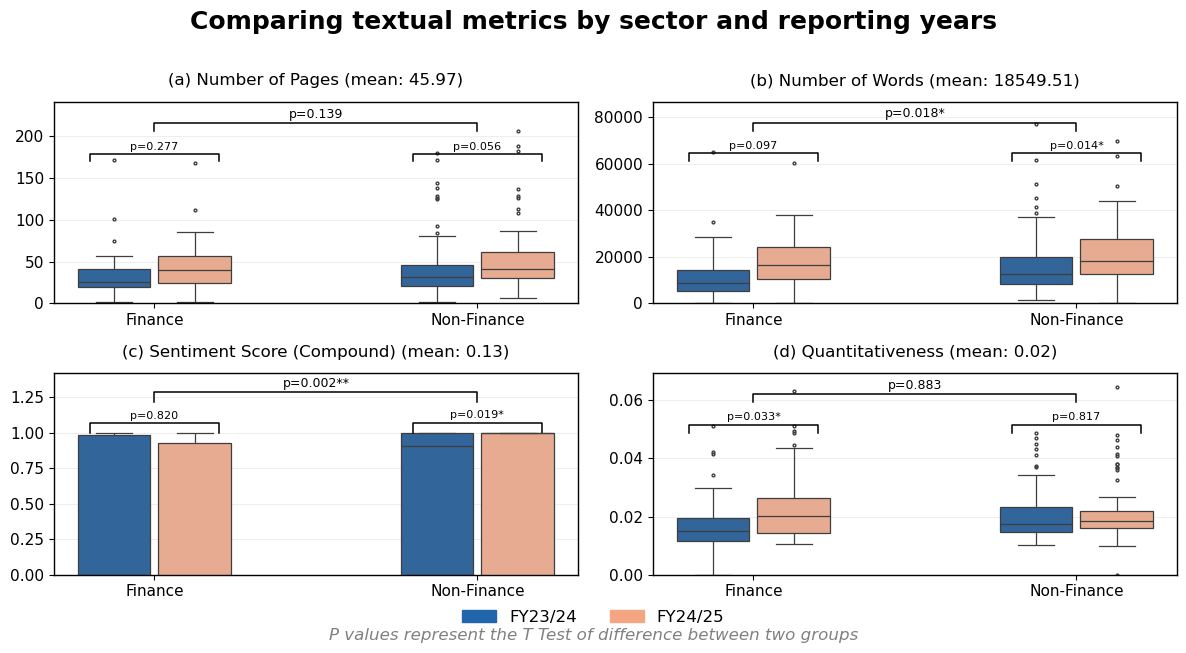

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from scipy import stats

rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#EBEBEB', 'grid.linewidth': 0.6,
})
# Derive short year labels from cohort names
def cohort_short_label(name):
    match = re.search(r'\((.+?)\)', str(name))
    return match.group(1) if match else name

c1_label = cohort_short_label(c1_name)  # '≤ Jun 2024'
c2_label = cohort_short_label(c2_name)  # 'Jul 2024 – Jun 2025'

COHORT_LABELS = {c1_name: 'FY23/24', c2_name: 'FY24/25'}

COHORT_COLORS = {c1_name: '#2166AC', c2_name: '#F4A582'}
metric_labels = {
    'pages_num':    '(a) Number of Pages',
    'number_words': '(b) Number of Words',
    'compound':     '(c) Sentiment Score (Compound)',
    #'digits':       'Digit Count',
    #'dollars':      'Dollar Mentions',
    #'percentages':  'Percentage Mentions',
    'quantitivate_relative': '(d) Quantitativeness'
}

def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

def draw_bracket(ax, x1, x2, y, p, fontsize=8):
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.1, color='black')
    ax.text((x1+x2)/2, y+h*1.3, f'p={p:.3f}{sig_label(p)}',
            ha='center', va='bottom', fontsize=fontsize, fontweight='normal')

# ── Pre-compute all t-tests ────────────────────────────────────────────────────
ttests = {}
for metric, label in metric_labels.items():
    fin_c1  = nlp_analysis[(nlp_analysis['sector']=='Finance')     & (nlp_analysis['cohort']==c1_name)][metric].dropna()
    fin_c2  = nlp_analysis[(nlp_analysis['sector']=='Finance')     & (nlp_analysis['cohort']==c2_name)][metric].dropna()
    nfin_c1 = nlp_analysis[(nlp_analysis['sector']=='Non-Finance') & (nlp_analysis['cohort']==c1_name)][metric].dropna()
    nfin_c2 = nlp_analysis[(nlp_analysis['sector']=='Non-Finance') & (nlp_analysis['cohort']==c2_name)][metric].dropna()
    fin_all  = nlp_analysis[nlp_analysis['sector']=='Finance'][metric].dropna()
    nfin_all = nlp_analysis[nlp_analysis['sector']=='Non-Finance'][metric].dropna()
    ttests[metric] = {
        'fin_cohort':  stats.ttest_ind(fin_c1,  fin_c2).pvalue  if len(fin_c1)>1  and len(fin_c2)>1  else 1,
        'nfin_cohort': stats.ttest_ind(nfin_c1, nfin_c2).pvalue if len(nfin_c1)>1 and len(nfin_c2)>1 else 1,
        'sector':      stats.ttest_ind(fin_all,  nfin_all).pvalue,
    }

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 6), facecolor='white')
fig.patch.set_facecolor('white')
axes = axes.flatten()

# seaborn hue dodge offset ≈ ±0.2 for 2 groups
DODGE = 0.2

for i, (metric,label) in enumerate(metric_labels.items()):
    ax = axes[i]
    sns.boxplot(
        data=nlp_analysis,
        x='sector', y=metric, hue='cohort',
        palette=COHORT_COLORS,
        order=['Finance', 'Non-Finance'],
        hue_order=[c1_name, c2_name],
        linewidth=0.9, fliersize=2, width=0.5, gap=0.1,
        ax=ax,
    )
    ax.set_facecolor('white')
    ax.get_legend().remove()

    p_fin   = ttests[metric]['fin_cohort']
    p_nfin  = ttests[metric]['nfin_cohort']
    p_sec   = ttests[metric]['sector']

    ymax  = nlp_analysis[metric].quantile(0.97)
    step  = ymax * 0.12

    # Bracket: Finance C1 vs C2
    draw_bracket(ax, 0-DODGE, 0+DODGE, ymax,          p_fin)
    # Bracket: Non-Finance C1 vs C2
    draw_bracket(ax, 1-DODGE, 1+DODGE, ymax,          p_nfin)
    # Bracket: Finance vs Non-Finance (higher)
    draw_bracket(ax, 0,       1,       ymax + step*1.8, p_sec, fontsize=9)

    ax.set_ylim(0, ymax + step * 3.5)
    ax.set_title(f'{metric_labels[metric]} (mean: {round(nlp_analysis[metric].mean(),2)})',
                  pad=12,fontweight='normal')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

# Shared legend
# In the shared legend block, replace:
patches = [mpatches.Patch(color=COHORT_COLORS[c], label=COHORT_LABELS[c])
           for c in [c1_name, c2_name]]
fig.legend(handles=patches, title='',
           loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=12)


fig.suptitle('Comparing textual metrics by sector and reporting years', fontsize=18, fontweight='bold', y=1.01)
fig.text(0.5, -0.04, 'P values represent the T Test of difference between two groups',
         ha='center', fontsize=12, color='grey', style='italic')

plt.tight_layout()
plt.savefig(os.path.join(FIG_FOLDER, 'Fig05_boxplot_sector_cohort_combined.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
